In [1]:
import numpy as np
import os, tqdm
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import corner

In [2]:
output_stat_dir = '../output'

In [3]:
# Astro params
params = ['ION_Tvir_MIN','R_BUBBLE_MAX','HII_EFF_FACTOR']
# Fisher_Param = ['$T_{Vir}$','$R_{Max}$','$\zeta$']
Fisher_Param = [r'$T_{Vir}~[10^4 \mathrm{K}]$', r'$R_{Max}$', r'$\zeta$']
nparams = len(params)
# parameter values for fiducial simulation
fid = np.array([10**4.7,15,30])

In [4]:
model_files = {}

model_files['PS 1D'] = {
    'AA* (100 h)' : os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_100hours_ps.txt'),
    'AA* (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_1000hours_ps.txt'),
    'AA4 (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AA4_1000hours_ps.txt'),
}

model_files['PS 2D'] = {
    'AA* (100 h)' : os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_100hours_PS2D_no_wedge_updated.txt'),
    'AA* (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_1000hours_PS2D_no_wedge_updated.txt'),
    'AA4 (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AA4_1000hours_PS2D_no_wedge_updated.txt'),
}

model_files['MAPS'] = {
    'AA* (100 h)' : os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_100hours_MAPS.txt'),
    'AA* (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_1000hours_MAPS.txt'),
    'AA4 (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AA4_1000hours_MAPS.txt'),
}

--- PS 1D ---
AA* (100 h): [  2.60980224 -74.00984429  10.65580795], [  7.69416935 107.49012485  48.48906772]
AA* (1000 h): [  3.97136144 -21.8123254   25.46304017], [ 6.24840612 59.05679523 34.42102202]
AA4 (1000 h): [ 4.56598905e+00 -1.73425714e-02  2.82661859e+01], [ 5.47692497 31.07877542 32.0333346 ]


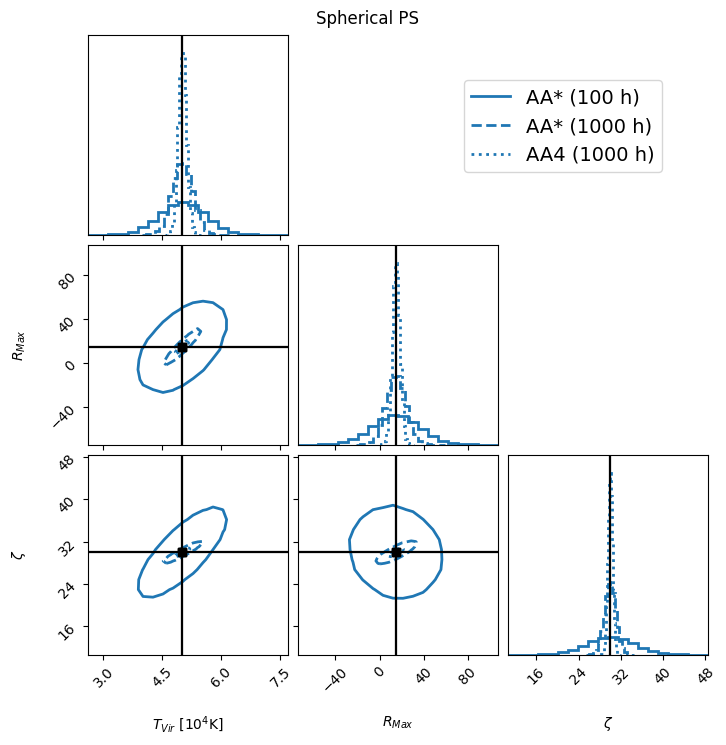

--- PS 2D ---
AA* (100 h): [-22.80023086 -94.44184691 -61.77802238], [ 29.43586511 123.49393711 117.43311392]
AA* (1000 h): [ -0.22832064 -43.76695294   3.20457427], [10.37927254 77.11580688 57.08128037]
AA4 (1000 h): [ -0.12434909 -42.84819311   2.01163803], [ 9.6785852  78.78119222 56.39973415]


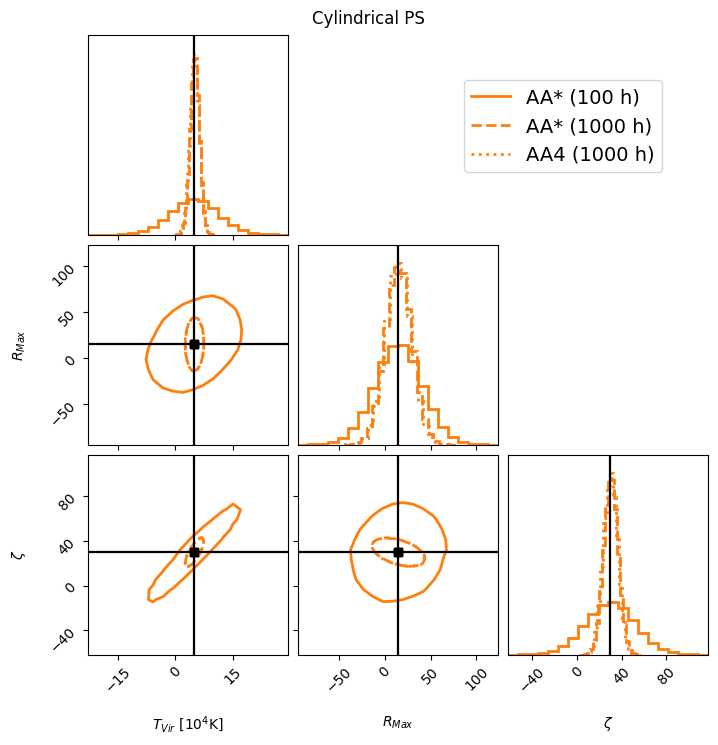

--- MAPS ---
AA* (100 h): [ 3.89229379  0.96653749 24.52576741], [ 6.41493961 27.5042653  35.63468344]
AA* (1000 h): [ 4.67420141 11.10286399 28.47010009], [ 5.35800431 18.37812546 31.48720589]
AA4 (1000 h): [ 4.65196936 12.00397771 28.56404354], [ 5.33328113 18.09317551 31.41625682]


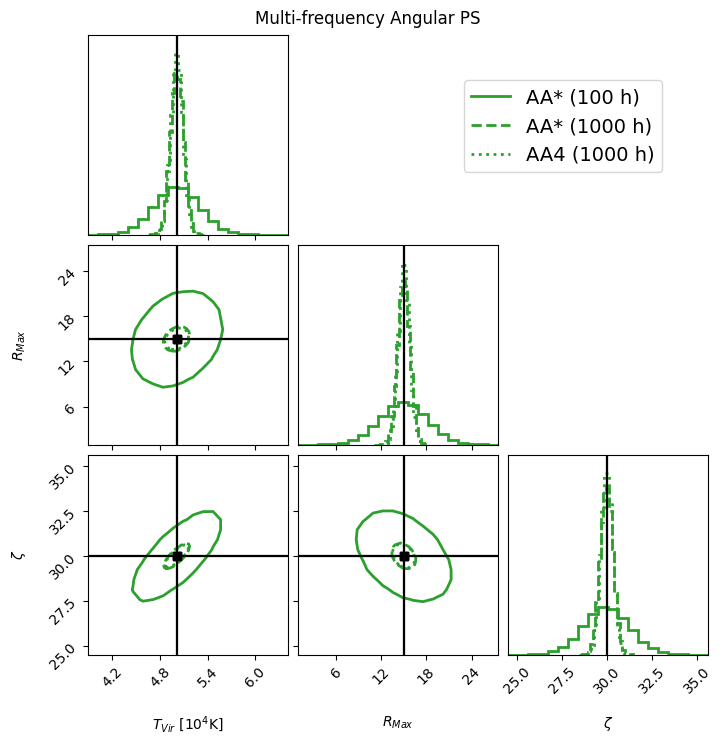

In [5]:
# --- Styling Definitions ---
# Define colors for each model type and linestyles for each case
style_guide = {
    'PS 1D': {'color': 'C0', 'label': 'Spherical PS'},
    'PS 2D': {'color': 'C1', 'label': 'Cylindrical PS'},
    'MAPS' : {'color': 'C2', 'label': 'Multi-frequency Angular PS'},
}

linestyles = {
    'AA* (100 h)' : ('-', 'AA* (100 h)'),
    'AA* (1000 h)': ('--', 'AA* (1000 h)'),
    'AA4 (1000 h)': (':', 'AA4 (1000 h)')
}

# --- Plotting ---
n_samples = 100000

truths = fid.copy()
truths[0] /= 1e4

levels = (0.864,) #(2-sigma, )
# levels = (0.675, 0.864) #(1-sigma, 2-sigma)

plot_cases = ['AA* (100 h)', 'AA* (1000 h)', 'AA4 (1000 h)']
# plot_cases = ['AA* (1000 h)', 'AA4 (1000 h)']

ranges = None

for model_type, cases in model_files.items():
    fig = None
    color = style_guide[model_type]['color']
    # Loop through the different observation cases
    print(f"--- {model_type} ---")
    for case_name, file_path in cases.items():
        if case_name in plot_cases:
            linestyle = linestyles[case_name][0]
            
            # Load covariance and generate samples
            cov = np.loadtxt(file_path)
            fisher_samples = np.random.multivariate_normal(fid, cov, size=n_samples)
            fisher_samples[:,0] /= 1e4
            print(f"{case_name}: {fisher_samples.min(axis=0)}, {fisher_samples.max(axis=0)}")
            
            # Add samples to the corner plot with specified styles
            fig = corner.corner(
                fisher_samples,
                fig=fig,
                labels=Fisher_Param,
                plot_datapoints=False,
                plot_density=False,
                levels=levels,
                truths=truths,
                truth_color='black',
                color=color, # Base color for the group
                # Apply linestyles to both 1D histograms and 2D contours
                hist_kwargs={'linestyle': linestyle, 'lw': 2, 'density': True},
                contour_kwargs={'linestyles': linestyle, 'linewidths': 2},
                range=ranges,
            )

    # --- Create Custom Legend ---
    # Create proxy artists for the legend
    legend_elements = []

    fig.suptitle(f"{style_guide[model_type]['label']}")
        
    # Add entries for observation cases (linestyles)
    for case_name, (ls, label) in linestyles.items():
        if case_name in plot_cases:
            legend_elements.append(mlines.Line2D(
                [], [], color=color, lw=2, linestyle=ls, label=label
            ))

    # Add the legend to the top-right corner of the figure
    fig.legend(handles=legend_elements, loc='upper right', fontsize=14, bbox_to_anchor=(0.90, 0.90))

    plt.show()

--- PS 1D ---
AA* (100 h): [  2.66898181 -68.33851582  11.01315698], [  7.63340344 108.185573    48.41663018]
AA* (1000 h): [  3.96994245 -22.10057696  25.81406897], [ 6.0875545  50.47486813 35.00094344]
AA4 (1000 h): [ 4.60860293 -0.37086517 28.31040495], [ 5.41578096 29.08675341 31.84838138]


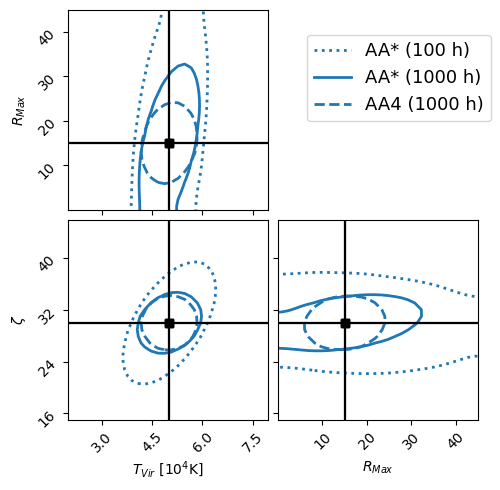

--- PS 1D ---
AA* (1000 h): [  3.95690021 -25.75844448  25.47689858], [ 6.15707686 54.47678758 34.6133406 ]
--- PS 2D ---
AA* (1000 h): [ -0.07981875 -48.90212222   2.05371996], [10.612412   82.68493787 58.51366077]
--- MAPS ---
AA* (1000 h): [ 4.67476202 11.49921515 28.49234382], [ 5.3666173  18.57355072 31.58503023]


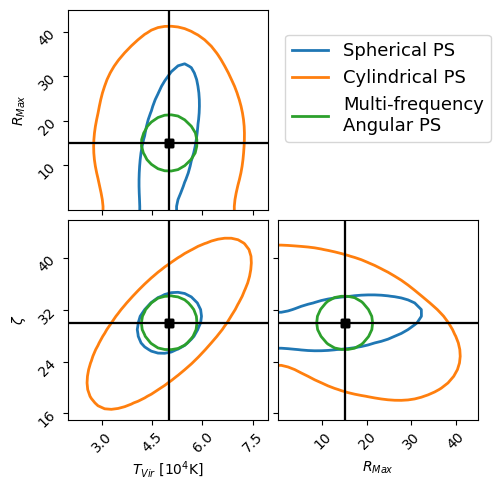

In [6]:
# --- Styling Definitions ---
# Define colors for each model type and linestyles for each case
style_guide = {
    'PS 1D': {'color': 'C0', 'label': 'Spherical PS'},
    'PS 2D': {'color': 'C1', 'label': 'Cylindrical PS'},
    'MAPS' : {'color': 'C2', 'label': 'Multi-frequency\nAngular PS'},
}

linestyles = {
    'AA* (100 h)' : (':', 'AA* (100 h)'),
    'AA* (1000 h)': ('-', 'AA* (1000 h)'),
    'AA4 (1000 h)': ('--', 'AA4 (1000 h)')
}

# --- Plotting ---
n_samples = 100000
remove_hist1d = True

truths = fid.copy()
truths[0] /= 1e4

levels = (0.864,) #(2-sigma, )
# levels = (0.675, 0.864) #(1-sigma, 2-sigma)

bins = 30
smooth = 2.0
smooth1d = None #2.0
labelpad = -0.1

ranges = [(2.0,7.95),(0,45),(15,46)]

plot_model = ['PS 1D']
plot_cases = ['AA* (100 h)', 'AA* (1000 h)', 'AA4 (1000 h)']

for model_type, cases in model_files.items():
    if model_type not in plot_model:
        continue
    fig = None
    color = style_guide[model_type]['color']
    # Loop through the different observation cases
    print(f"--- {model_type} ---")
    for case_name, file_path in cases.items():
        if case_name in plot_cases:
            linestyle = linestyles[case_name][0]
            
            # Load covariance and generate samples
            cov = np.loadtxt(file_path)
            fisher_samples = np.random.multivariate_normal(fid, cov, size=n_samples)
            fisher_samples[:,0] /= 1e4
            print(f"{case_name}: {fisher_samples.min(axis=0)}, {fisher_samples.max(axis=0)}")
            
            # Add samples to the corner plot with specified styles
            fig = corner.corner(
                fisher_samples,
                bins=bins,
                fig=fig,
                labels=Fisher_Param,
                plot_datapoints=False,
                plot_density=False,
                levels=levels,
                truths=truths,
                truth_color='black',
                color=color, # Base color for the group
                # Apply linestyles to both 1D histograms and 2D contours
                hist_kwargs={'linestyle': linestyle, 'lw': 2, 'density': True},
                contour_kwargs={'linestyles': linestyle, 'linewidths': 2},
                range=ranges,
                smooth=smooth,
                smooth1d=smooth1d,
                labelpad=labelpad,
            )

    # --- Create Custom Legend ---
    # Create proxy artists for the legend
    legend_elements = []

    # fig.suptitle(f"{style_guide[model_type]['label']}")
        
    # Add entries for observation cases (linestyles)
    for case_name, (ls, label) in linestyles.items():
        if case_name in plot_cases:
            legend_elements.append(mlines.Line2D(
                [], [], color=color, lw=2, linestyle=ls, label=label
            ))

    if remove_hist1d:
        # === REMOVE UNUSED AXES ===
        ndim = len(Fisher_Param)
        axes = np.array(fig.axes).reshape((ndim, ndim))
        for i in range(ndim):
            for j in range(ndim):
                if i <= j:
                    fig.delaxes(axes[i, j])  # remove diagonal + upper triangle
        # Add the legend to the top-right corner of the figure
        fig.legend(handles=legend_elements, loc='upper right', fontsize=13, bbox_to_anchor=(0.70, 0.65))
    else:
        # Add the legend to the top-right corner of the figure
        fig.legend(handles=legend_elements, loc='upper right', fontsize=13, bbox_to_anchor=(0.90, 0.90))

plt.savefig('../figures/PS1D_Corner_3scenarios.pdf',bbox_inches='tight')
plt.show()

ranges = [(2.0,7.95),(0,45),(15,46)]

plot_model = ['PS 1D', 'PS 2D', 'MAPS']
plot_cases = ['AA* (1000 h)']

fig = None
for model_type, cases in model_files.items():
    if model_type not in plot_model:
        continue
    color = style_guide[model_type]['color']
    # Loop through the different observation cases
    print(f"--- {model_type} ---")
    for case_name, file_path in cases.items():
        if case_name in plot_cases:
            linestyle = linestyles[case_name][0]
            
            # Load covariance and generate samples
            cov = np.loadtxt(file_path)
            fisher_samples = np.random.multivariate_normal(fid, cov, size=n_samples)
            fisher_samples[:,0] /= 1e4
            print(f"{case_name}: {fisher_samples.min(axis=0)}, {fisher_samples.max(axis=0)}")
            
            # Add samples to the corner plot with specified styles
            fig = corner.corner(
                fisher_samples,
                bins=bins,
                fig=fig,
                labels=Fisher_Param,
                plot_datapoints=False,
                plot_density=False,
                levels=levels,
                truths=truths,
                truth_color='black',
                color=color, # Base color for the group
                # Apply linestyles to both 1D histograms and 2D contours
                hist_kwargs={'linestyle': linestyle, 'lw': 2, 'density': True},
                contour_kwargs={'linestyles': linestyle, 'linewidths': 2},
                range=ranges,
                smooth=smooth,
                smooth1d=smooth1d,
                labelpad=labelpad,
            )

# --- Create Custom Legend ---
# Create proxy artists for the legend
legend_elements = []

# Add entries for model types (colors)
for model_type, styles in style_guide.items():
    legend_elements.append(mlines.Line2D(
        [], [], color=styles['color'], lw=2, label=styles['label']
    ))

if remove_hist1d:
    # === REMOVE UNUSED AXES ===
    ndim = len(Fisher_Param)
    axes = np.array(fig.axes).reshape((ndim, ndim))
    for i in range(ndim):
        for j in range(ndim):
            if i <= j:
                fig.delaxes(axes[i, j])  # remove diagonal + upper triangle
    # Add the legend to the top-right corner of the figure
    fig.legend(handles=legend_elements, loc='upper right', fontsize=13, bbox_to_anchor=(0.70, 0.65))
else:
    # Add the legend to the top-right corner of the figure
    fig.legend(handles=legend_elements, loc='upper right', fontsize=13, bbox_to_anchor=(0.90, 0.90))
plt.savefig('../figures/PS1D_PS2D_MAPS_Corner.pdf',bbox_inches='tight')
plt.show()